In [33]:
# =============================================================================
# ANALYSE EXPLORATOIRE DES DONNÉES DE SOL - SoilHive
# =============================================================================
# Objectifs:
#   1. Comprendre la distribution des propriétés du sol
#   2. Analyser la variabilité verticale (profondeur)
#   3. Examiner l'évolution temporelle
#   4. Explorer la variabilité spatiale
#   5. Identifier les opportunités pour la modélisation ML
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style scientifique sobre
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.figsize'] = (10, 6)

# Palette de couleurs sobre (3 couleurs principales)
COLORS = ['#2c3e50', '#3498db', '#95a5a6']
COLORS_DEPTH = ['#1a5276', '#2980b9', '#5dade2', '#85c1e9']

# Chargement des données
df = pd.read_csv('data/combined_output_data_points.csv')
print(f"Dataset chargé: {df.shape[0]:,} observations | {df.shape[1]} variables")
print(f"Période: {df['sampling_date'].min():.0f} - {df['sampling_date'].max():.0f}")

Dataset chargé: 1,032,331 observations | 14 variables
Période: 1928 - 2017


## 1. VUE D'ENSEMBLE DU DATASET

**Objectif:** Comprendre la structure, la qualité et la couverture des données.

In [34]:
# 1.1 Aperçu structurel
print("=" * 60)
print("STRUCTURE DU DATASET")
print("=" * 60)

# Types de données et valeurs manquantes
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Non-Null': df.count(),
    'Null (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique': df.nunique()
})
print(info_df)
print()

# Statistiques clés
print("=" * 60)
print("MÉTRIQUES CLÉS")
print("=" * 60)
print(f"• Propriétés du sol mesurées: {df['property'].nunique()}")
print(f"• Sources de données: {df['data_source'].nunique()}")
print(f"• Localisations uniques: {df[['lat', 'lon']].drop_duplicates().shape[0]:,}")
print(f"• Index H3 uniques (cellules spatiales): {df['h3_index'].nunique():,}")
print(f"• Plage de profondeur: {df['upper_depth_cm'].min():.0f} - {df['lower_depth_cm'].max():.0f} cm")

STRUCTURE DU DATASET
                     Type  Non-Null  Null (%)  Unique
id                  int64   1032331      0.00   16213
lat               float64   1032331      0.00   30384
lon               float64   1032331      0.00   30493
property           object   1032331      0.00      20
original_name      object   1032331      0.00      54
upper_depth_cm    float64   1017485      1.44     238
lower_depth_cm    float64   1017485      1.44     269
value             float64   1031390      0.09   13309
unit               object    762802     26.11      11
sampling_date     float64    495152     52.04      69
license            object   1032331      0.00       6
h3_index           object   1032331      0.00     613
publication_date   object   1032331      0.00       3
data_source        object   1032331      0.00       3

MÉTRIQUES CLÉS
• Propriétés du sol mesurées: 20
• Sources de données: 3
• Localisations uniques: 31,124
• Index H3 uniques (cellules spatiales): 613
• Plage de profonde

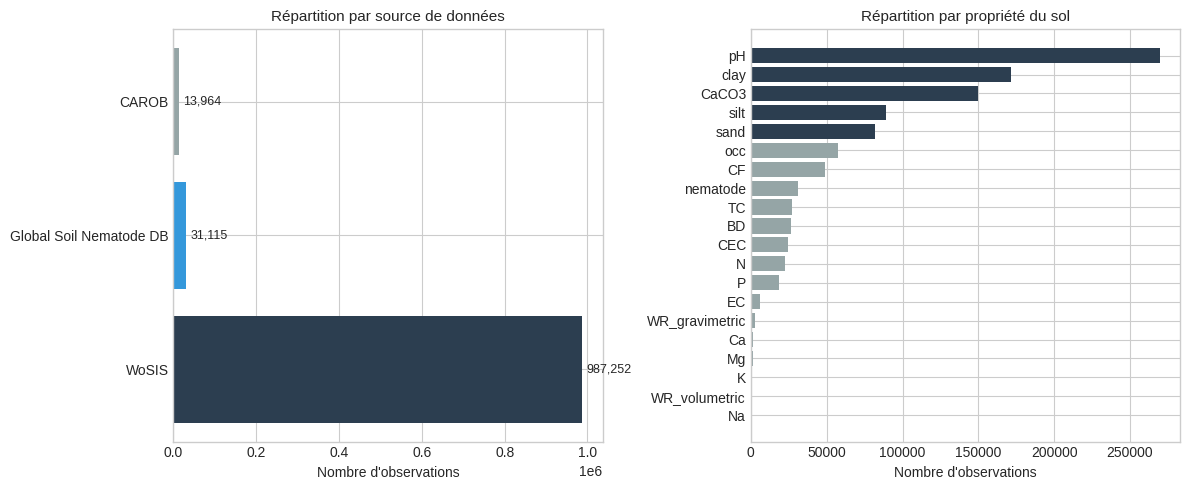


📌 INSIGHT: La source WoSIS domine largement. Les propriétés texturales
   (sand, clay, silt) et le pH sont les plus représentées.


In [35]:
# 1.2 Distribution par source de données et propriété
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution par source
source_counts = df['data_source'].value_counts()
ax1 = axes[0]
bars = ax1.barh(source_counts.index, source_counts.values, color=COLORS[:len(source_counts)])
ax1.set_xlabel('Nombre d\'observations')
ax1.set_title('Répartition par source de données')
for bar, val in zip(bars, source_counts.values):
    ax1.text(val + max(source_counts)*0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:,}', va='center', fontsize=9)

# Distribution par propriété
prop_counts = df['property'].value_counts()
ax2 = axes[1]
colors_prop = [COLORS[0] if i < 5 else COLORS[2] for i in range(len(prop_counts))]
bars = ax2.barh(prop_counts.index, prop_counts.values, color=colors_prop)
ax2.set_xlabel('Nombre d\'observations')
ax2.set_title('Répartition par propriété du sol')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Insight
print("\n📌 INSIGHT: La source WoSIS domine largement. Les propriétés texturales")
print("   (sand, clay, silt) et le pH sont les plus représentées.")

## 2. DISTRIBUTION DES PROPRIÉTÉS DU SOL

**Objectif:** Caractériser la distribution statistique de chaque propriété, identifier les valeurs aberrantes et les asymétries.

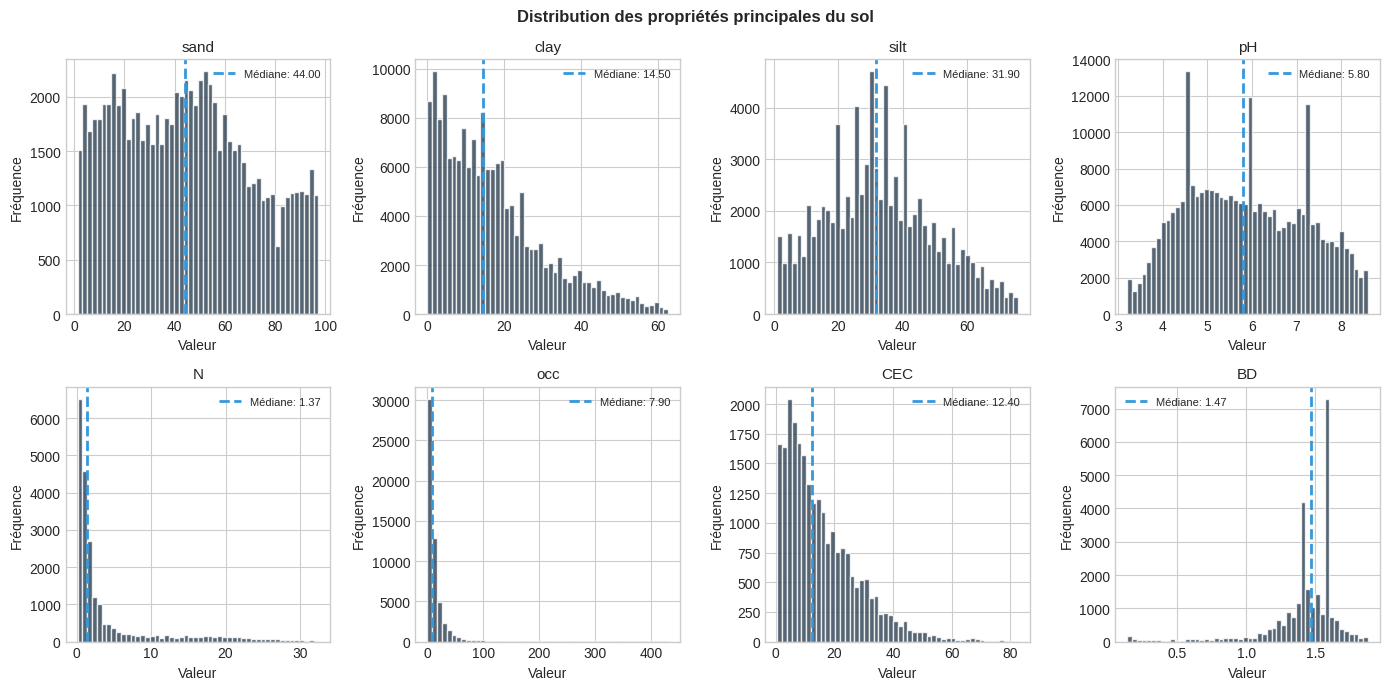


📌 INSIGHT: Le pH montre une distribution bimodale (sols acides vs alcalins).
   Les propriétés texturales (sand, clay, silt) sont fortement asymétriques.


In [37]:
# 2.2 Distribution des propriétés principales (histogrammes)
main_props = ['sand', 'clay', 'silt', 'pH', 'N', 'occ', 'CEC', 'BD']
available_props = [p for p in main_props if p in df['property'].unique()]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, prop in enumerate(available_props):
    ax = axes[i]
    data = df[df['property'] == prop]['value'].dropna()
    
    # Enlever les valeurs extrêmes pour la visualisation (percentile 1-99)
    q1, q99 = data.quantile([0.01, 0.99])
    data_clean = data[(data >= q1) & (data <= q99)]
    
    ax.hist(data_clean, bins=50, color=COLORS[0], edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color=COLORS[1], linestyle='--', linewidth=2, label=f'Médiane: {data.median():.2f}')
    ax.set_title(f'{prop}')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)

# Masquer les axes inutilisés
for j in range(len(available_props), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution des propriétés principales du sol', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 INSIGHT: Le pH montre une distribution bimodale (sols acides vs alcalins).")
print("   Les propriétés texturales (sand, clay, silt) sont fortement asymétriques.")

## 3. VARIABILITÉ VERTICALE (PROFONDEUR)

**Objectif:** Analyser comment les propriétés du sol varient avec la profondeur - essentiel pour la modélisation des profils de sol et les recommandations d'engrais.

In [38]:
# 3.1 Création de classes de profondeur
df['depth_mid'] = (df['upper_depth_cm'] + df['lower_depth_cm']) / 2
df['depth_class'] = pd.cut(df['depth_mid'], 
                           bins=[0, 30, 60, 100, 200, np.inf],
                           labels=['0-30', '30-60', '60-100', '100-200', '>200'])

# Distribution des mesures par profondeur
depth_dist = df['depth_class'].value_counts().sort_index()
print("Distribution des observations par classe de profondeur:")
print(depth_dist)
print(f"\nProfondeur médiane des échantillons: {df['depth_mid'].median():.0f} cm")

Distribution des observations par classe de profondeur:
depth_class
0-30       403609
30-60      252482
60-100     202010
100-200    157520
>200         1864
Name: count, dtype: int64

Profondeur médiane des échantillons: 40 cm


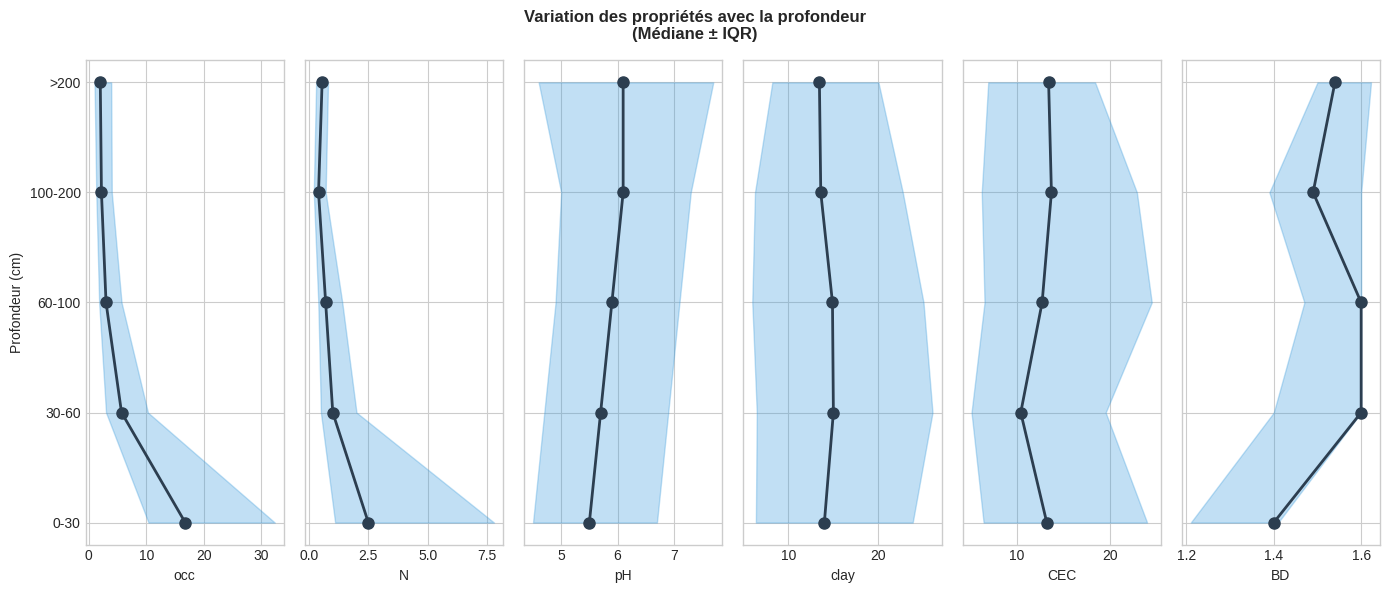


📌 INSIGHT AGRONOMIQUE:
   • Matière organique (occ) et azote (N): décroissance rapide avec la profondeur
   • pH: tendance à augmenter en profondeur (moins acide)
   • Argile (clay): accumulation possible dans les horizons intermédiaires (illuviation)
   ➜ Implication ML: la profondeur est une feature critique pour les modèles


In [39]:
key_props = ['occ', 'N', 'pH', 'clay', 'CEC', 'BD']
available_key = [p for p in key_props if p in df['property'].unique()]

fig, axes = plt.subplots(1, len(available_key), figsize=(14, 6), sharey=True)

for i, prop in enumerate(available_key):
    ax = axes[i]
    prop_data = df[df['property'] == prop].dropna(subset=['depth_class', 'value'])
    
    # Calculer médiane et IQR par classe de profondeur
    stats = prop_data.groupby('depth_class')['value'].agg(['median', 
        lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
    stats.columns = ['depth_class', 'median', 'q25', 'q75']
    
    # Convertir en positions numériques (inversées pour que surface soit en haut)
    positions = {'0-30': 0, '30-60': 1, '60-100': 2, '100-200': 3, '>200': 4}
    stats['y_pos'] = stats['depth_class'].map(positions)
    stats = stats.sort_values('y_pos')
    
    # Tracer le profil
    ax.plot(stats['median'], stats['y_pos'], 'o-', color=COLORS[0], linewidth=2, markersize=8)
    ax.fill_betweenx(stats['y_pos'], stats['q25'], stats['q75'], alpha=0.3, color=COLORS[1])
    
    ax.set_xlabel(prop)
    ax.set_yticks(range(5))
    ax.set_yticklabels(['0-30', '30-60', '60-100', '100-200', '>200'])
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel('Profondeur (cm)')

plt.suptitle('Variation des propriétés avec la profondeur\n(Médiane ± IQR)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 INSIGHT AGRONOMIQUE:")
print("   • Matière organique (occ) et azote (N): décroissance rapide avec la profondeur")
print("   • pH: tendance à augmenter en profondeur (moins acide)")
print("   • Argile (clay): accumulation possible dans les horizons intermédiaires (illuviation)")
print("   ➜ Implication ML: la profondeur est une feature critique pour les modèles")

In [27]:
df['property'].value_counts().index

Index(['pH', 'clay', 'CaCO3', 'silt', 'sand', 'occ', 'CF', 'nematode', 'TC',
       'BD', 'CEC', 'N', 'P', 'EC', 'WR_gravimetric', 'Ca', 'Mg', 'K',
       'WR_volumetric', 'Na'],
      dtype='object', name='property')

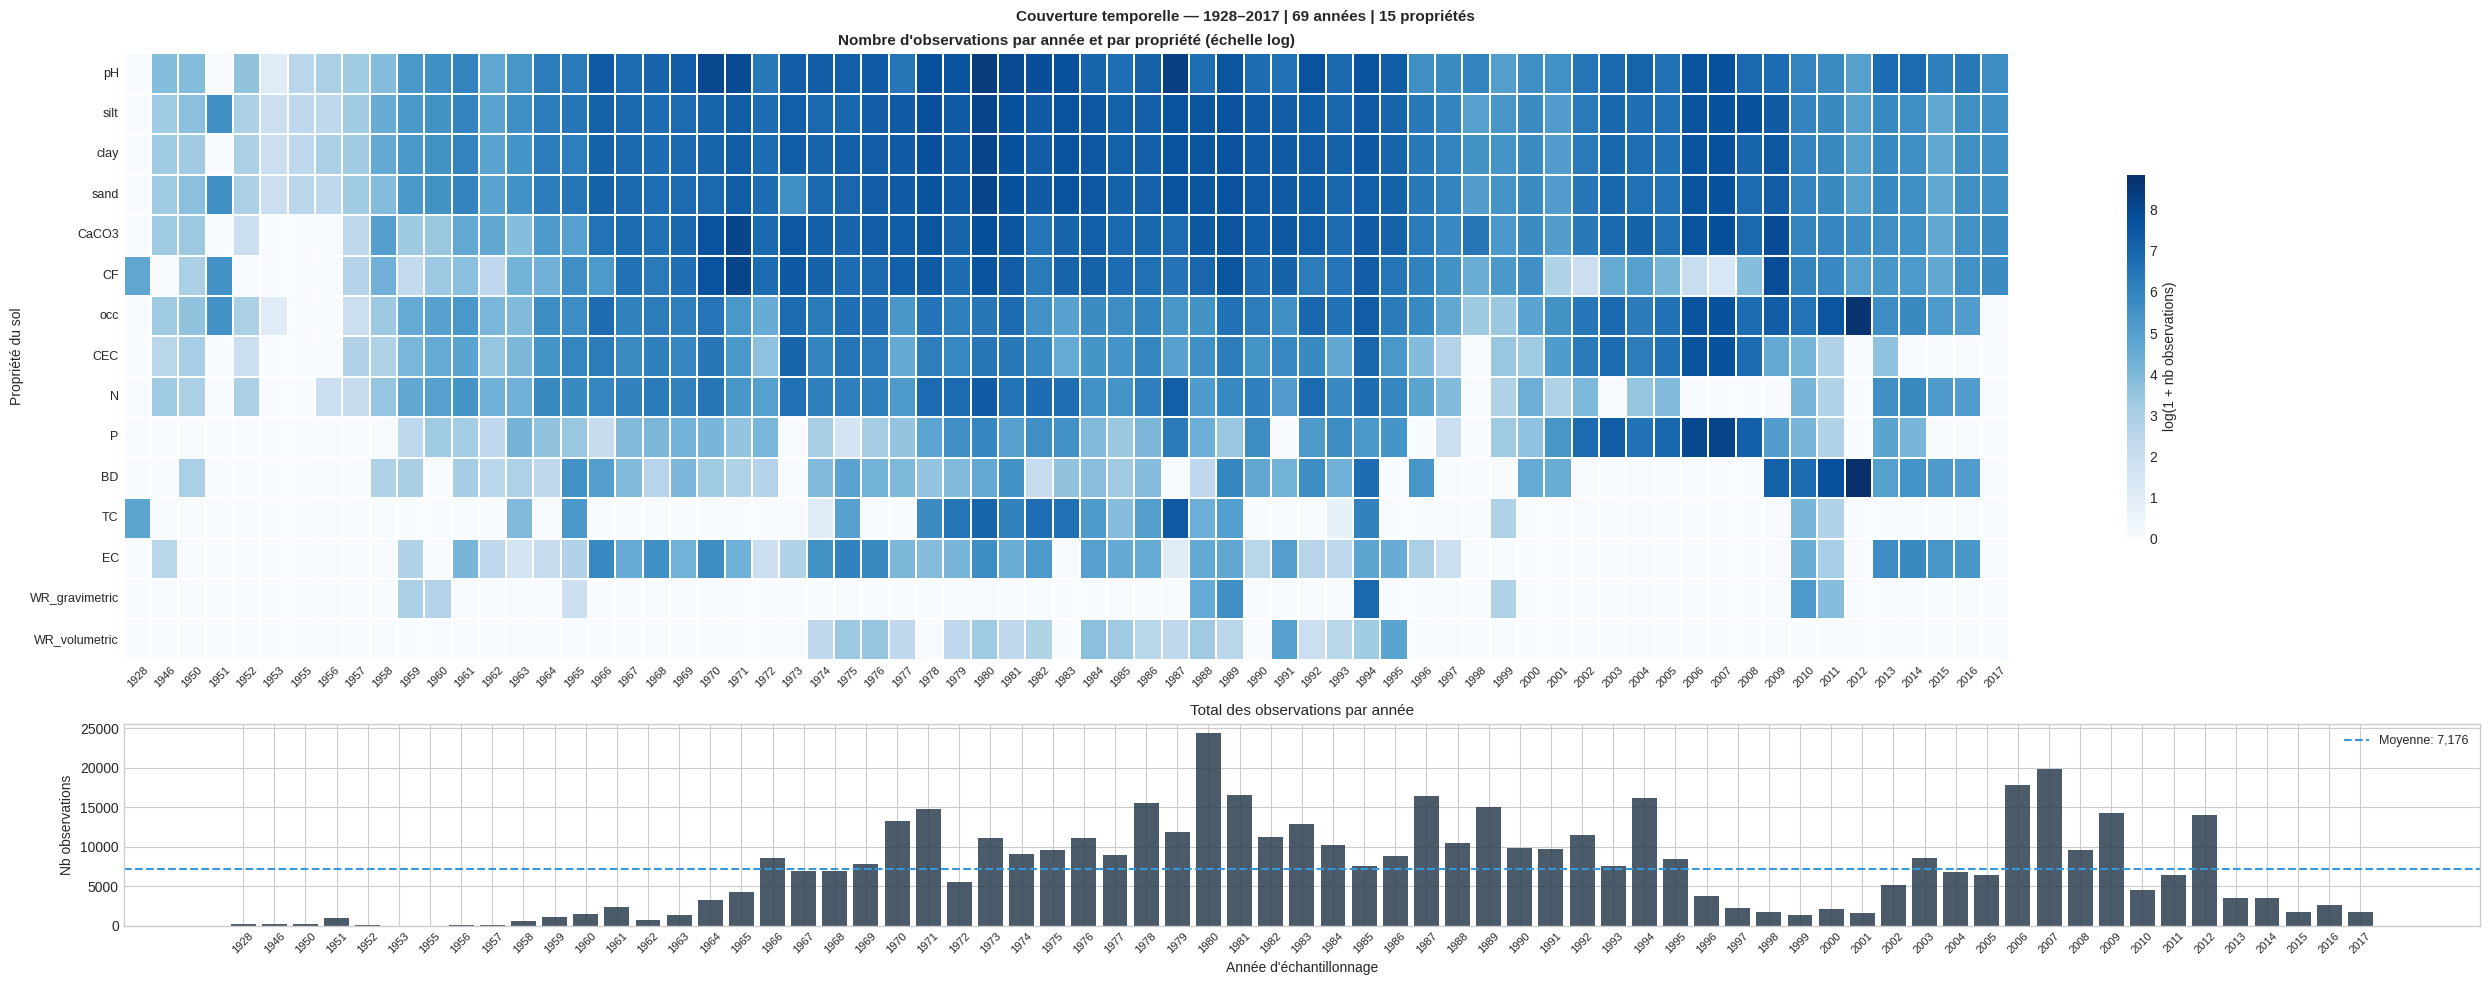


📊 STATISTIQUES TEMPORELLES:
   • Période couverte  : 1928 – 2017
   • Données avec date : 495,152 / 1,032,331 (48.0%)
   • Année la plus active : 1980 (24,326 observations)


In [42]:
df_temporal = df.dropna(subset=['sampling_date']).copy()
df_temporal['year'] = df_temporal['sampling_date'].astype(int)

# Matrice propriété × année (counts)
obs_matrix = (
    df_temporal.groupby(['property', 'year'])
    .size()
    .unstack(fill_value=0)
)

# Trier les propriétés par nombre total d'observations (décroissant)
obs_matrix = obs_matrix.loc[obs_matrix.sum(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(2, 1, figsize=(25, 10),
                         gridspec_kw={'height_ratios': [3, 1]})

# ── Heatmap : propriété × année ──────────────────────────────────────────────
ax1 = axes[0]
# Log1p pour atténuer l'effet des propriétés très dominantes (pH, clay…)
obs_log = np.log1p(obs_matrix)
sns.heatmap(
    obs_log, ax=ax1,
    cmap='Blues',
    linewidths=0.2,
    cbar_kws={'label': 'log(1 + nb observations)', 'shrink': 0.6}
)
ax1.set_xlabel('')
ax1.set_ylabel('Propriété du sol')
ax1.set_title('Nombre d\'observations par année et par propriété (échelle log)',
              fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', labelsize=9)

# ── Bar chart : total par année (toutes propriétés) ──────────────────────────
ax2 = axes[1]
total_per_year = df_temporal.groupby('year').size().sort_index()
years = total_per_year.index.astype(str)
x = range(len(years))

ax2.bar(x, total_per_year.values, color=COLORS[0], alpha=0.85, width=0.8)
ax2.axhline(total_per_year.mean(), color=COLORS[1], linestyle='--', linewidth=1.5,
            label=f'Moyenne: {int(total_per_year.mean()):,}')
ax2.set_xticks(x)
ax2.set_xticklabels(years, rotation=45, fontsize=8)
ax2.set_xlabel('Année d\'échantillonnage')
ax2.set_ylabel('Nb observations')
ax2.set_title('Total des observations par année')
ax2.legend(fontsize=9)

plt.suptitle(
    f'Couverture temporelle — {int(df_temporal["year"].min())}–{int(df_temporal["year"].max())} '
    f'| {df_temporal["year"].nunique()} années | {df_temporal["property"].nunique()} propriétés',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"\n📊 STATISTIQUES TEMPORELLES:")
print(f"   • Période couverte  : {int(df_temporal['year'].min())} – {int(df_temporal['year'].max())}")
print(f"   • Données avec date : {len(df_temporal):,} / {len(df):,} ({len(df_temporal)/len(df)*100:.1f}%)")
peak_year = total_per_year.idxmax()
print(f"   • Année la plus active : {peak_year} ({total_per_year[peak_year]:,} observations)")

## 6. COMPARAISON DES SOURCES DE DONNÉES

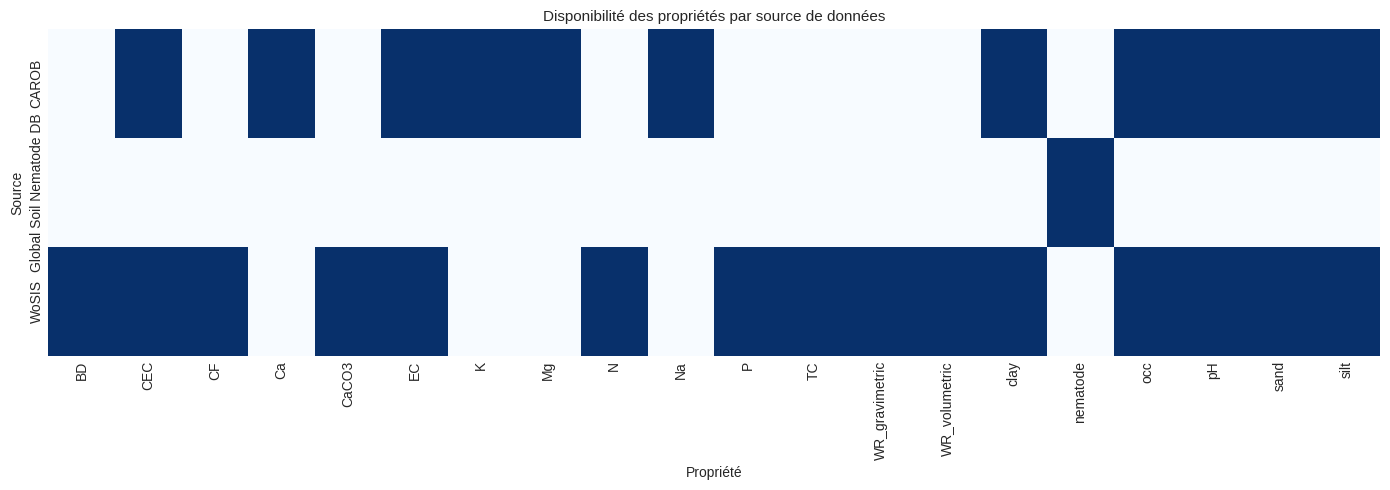


📊 PROPRIÉTÉS PAR SOURCE:
   • WoSIS: 15 propriétés - BD, CEC, CF, CaCO3, EC, N, P, TC...
   • Global Soil Nematode DB: 1 propriétés - nematode...
   • CAROB: 11 propriétés - CEC, Ca, EC, K, Mg, Na, clay, occ...


In [ ]:
source_props = df.groupby(['data_source', 'property']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
source_props_binary = (source_props > 0).astype(int)
sns.heatmap(source_props_binary, cmap='Blues', cbar=False, annot=False, ax=ax)
ax.set_title('Disponibilité des propriétés par source de données')
ax.set_xlabel('Propriété')
ax.set_ylabel('Source')

plt.tight_layout()
plt.show()

print("\n📊 PROPRIÉTÉS PAR SOURCE:")
for source in df['data_source'].unique():
    props = df[df['data_source'] == source]['property'].unique()
    print(f"   • {source}: {len(props)} propriétés - {', '.join(sorted(props)[:8])}...")

## 7. CORRÉLATIONS ENTRE PROPRIÉTÉS

**Objectif:** Identifier les relations entre propriétés du sol - utile pour la sélection de features et la compréhension pédologique.

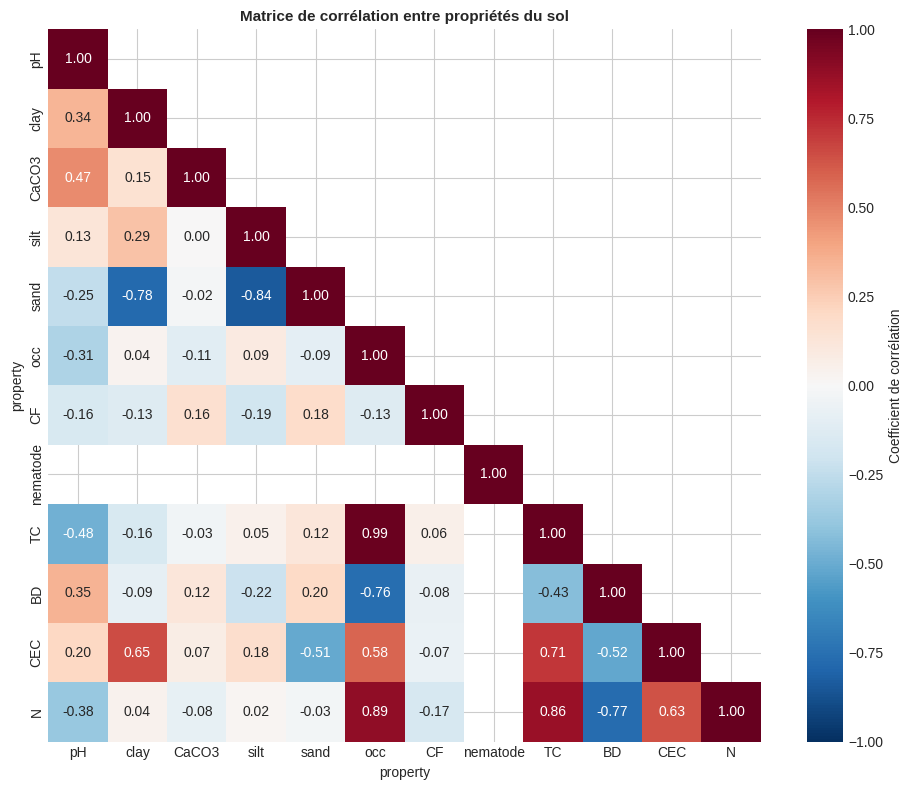


📊 CORRÉLATIONS FORTES (|r| > 0.5):
   clay ↔ sand: r = -0.78
   clay ↔ CEC: r = +0.65
   silt ↔ sand: r = -0.84
   sand ↔ CEC: r = -0.51
   occ ↔ TC: r = +0.99
   occ ↔ BD: r = -0.76
   occ ↔ CEC: r = +0.58
   occ ↔ N: r = +0.89
   TC ↔ CEC: r = +0.71
   TC ↔ N: r = +0.86
   BD ↔ CEC: r = -0.52
   BD ↔ N: r = -0.77
   CEC ↔ N: r = +0.63


In [43]:
# 7.1 Matrice de corrélation entre propriétés
# Pivoter les données pour avoir une propriété par colonne par localisation
df_pivot = df.pivot_table(
    values='value',
    index=['lat', 'lon', 'depth_mid'],
    columns='property',
    aggfunc='mean'
).reset_index()

# Sélectionner les propriétés les plus courantes
prop_counts = df['property'].value_counts()
top_props = prop_counts[prop_counts > 10000].index.tolist()[:12]

# Matrice de corrélation
if len(top_props) > 3:
    corr_matrix = df_pivot[top_props].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, vmin=-1, vmax=1, ax=ax, square=True,
                cbar_kws={'label': 'Coefficient de corrélation'})
    ax.set_title('Matrice de corrélation entre propriétés du sol', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Identifier les corrélations fortes
    print("\n📊 CORRÉLATIONS FORTES (|r| > 0.5):")
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.5:
                sign = "+" if r > 0 else "-"
                print(f"   {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: r = {sign}{abs(r):.2f}")

## 8. SYNTHÈSE ET IMPLICATIONS POUR LA MODÉLISATION

**Objectif:** Résumer les findings clés et formuler des recommandations pour la modélisation ML (recommandation d'engrais, prédiction spatiale).

---

## CONCLUSIONS

### Points forts du dataset
1. **Volume conséquent** (~1M observations) avec bonne couverture géographique
2. **Propriétés agronomiques clés** disponibles (pH, N, texture, CEC)
3. **Index H3** pré-calculé facilitant l'agrégation spatiale
4. **Multi-source** permettant la validation croisée

### Limitations identifiées
1. **Biais temporel**: majorité des données des années 1970-1980
2. **Couverture spatiale hétérogène**: zones sous-échantillonnées
3. **Outliers significatifs**: nécessite un nettoyage rigoureux
4. **Données manquantes**: notamment pour les nutriments (P, K)

### Recommandations pour la modélisation ML
- **Pour recommandation d'engrais**: Focus sur horizon 0-30 cm, features clés = pH, N, occ, texture
- **Pour prédiction spatiale**: Utiliser krigeage ou GP avec features H3, attention aux zones clairsemées
- **Validation**: Stratifier par source et par période pour éviter le data leakage